<a href="https://colab.research.google.com/github/kayurh/data_analytics/blob/main/6_2_lecture_Kayur_Amour_Harry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lesson 6 – Relationships Between Variables 2: When Correlation Does Not Work

In the **6.1 notebook**, we worked with numerical variables, so using **correlation** was a natural choice:  
scatterplot → correlation matrix → Pearson vs. Spearman → interpretation.

However, in real-world data we often encounter **categorical** variables (text/label-like variables),
where correlation does not make much sense (there is no meaningful “distance” between two products or two categories).

In this **6.2 notebook**, we show how to examine **co-occurrence**
instead of correlation when working with categorical data, using a classic **market basket** example:

- **support**: how frequent an item is (in what percentage of baskets it appears)
- **support(A ∩ B)**: how frequent two items occur together

The goal is to see that: **for numerical data, correlation** is appropriate,  
while for **categorical data, frequency + co-occurrence + rules** is the right way of thinking.



## Market Basket Dataset
- This dataset is a classic **market basket** type of dataset.
- Each row represents one **purchased item**, linked to a specific customer and date.

Columns (features)

- **Member_number** – customer identifier (member / client ID)  
- **Date** – date of purchase  
- **itemDescription** – name / category of the purchased item

Important concept: transaction (shopping basket)

Since there is no separate block or invoice identifier, we define a “basket” as follows:

- **transaction_id = (Member_number, Date)**

That is: the items purchased by a given customer **on the same day** belong to the same transaction.

In [ ]:
import pandas as pd
import numpy as np

# Load the data
# https://drive.google.com/file/d/1fmCcMbBwZrL6eNsv6Y9L_CxUx9VNPnSs/view?usp=sharing+
file_id = "1fmCcMbBwZrL6eNsv6Y9L_CxUx9VNPnSs"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url)
df.head()


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


## Categorical Relationships: Frequency (Support) Instead of Correlation

For numerical variables we often compute correlation, but for **categorical variables** this usually does not make sense
(there is no natural “distance” between categories).

In such cases we examine **which categories occur frequently together**.
This leads to the idea of association rules (Apriori):

- **support(A)** = the percentage of cases in which A occurs
$$
\text{support}(A) = \frac{\#\{\text{transactions containing } A\}}{N}
$$

- **support(A ∩ B)** = the percentage of cases in which A and B occur together

$$
\text{support}(A \cap B) = \frac{\#\{\text{transactions containing both } A \text{ and } B\}}{N}
$$

where:
- $N$ is the total number of transactions  
- the numerator counts how many transactions contain the given item(s)

In [ ]:
# Fix the date format (based on the example: 21-07-2015 -> dayfirst=True)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Transaction identifier: member + day
df["transaction_id"] = df["Member_number"].astype(str) + "_" + df["Date"].dt.strftime("%Y-%m-%d")

# List of items belonging to one transaction (remove duplicates using set)
transactions = df.groupby("transaction_id")["itemDescription"].apply(lambda s: sorted(set(s)))

N = len(transactions)  # number of transactions
N

14963

In [ ]:
# Flattening: lists of transactions -> one long series
all_items = transactions.explode()
all_items.head(20)

,itemDescription
transaction_id,
1000_2014-06-24,pastry
1000_2014-06-24,salty snack
1000_2014-06-24,whole milk
1000_2015-03-15,sausage
1000_2015-03-15,semi-finished bread
1000_2015-03-15,whole milk
1000_2015-03-15,yogurt
1000_2015-05-27,pickled vegetables
1000_2015-05-27,soda


In [ ]:
# Support = number of occurrences / number of transactions
support_1 = (all_items.value_counts() / N).sort_values(ascending=False)
support_1.head(10)

,count
itemDescription,
whole milk,0.157923
other vegetables,0.122101
rolls/buns,0.110005
soda,0.097106
yogurt,0.085879
root vegetables,0.069572
tropical fruit,0.067767
bottled water,0.060683
sausage,0.060349


**What does the table show?**

This is the **support table for single items** (1-item support).

- Each row represents a **product** (item), e.g., *whole milk*, *other vegetables*.
- The number next to it shows in what percentage of **baskets (transactions)** the item appears.

Example: *whole milk = 0.158*  
→ *whole milk* appears in about **15.8%** of the baskets.

In [ ]:
from itertools import combinations

# 1) from each basket we generate all (A,B) item pairs
pairs = transactions.apply(lambda items: list(combinations(items, 2))).explode()

# 2) support(A ∩ B) = number of pairs / number of baskets
pair_support = (pairs.value_counts() / N).sort_values(ascending=False)

# 10 most frequent item pairs
pair_support.head(10)

,count
itemDescription,
"(other vegetables, whole milk)",0.014837
"(rolls/buns, whole milk)",0.013968
"(soda, whole milk)",0.011629
"(whole milk, yogurt)",0.011161
"(other vegetables, rolls/buns)",0.010559
"(other vegetables, soda)",0.009691
"(sausage, whole milk)",0.008955
"(tropical fruit, whole milk)",0.008220
"(other vegetables, yogurt)",0.008087


### What does this list show?

This table shows the **2-item support** in the shopping basket dataset:  
the proportion of transactions in which **two products appear together in the same basket (transaction)**.

- Each row represents a **product pair**, e.g. *(other vegetables, whole milk)*.
- The value next to it is the **support(A ∩ B)**: the percentage of baskets in which **both products appear together**.

Example: *(other vegetables, whole milk) = 0.0148*  
→ in about **1.48%** of baskets, *other vegetables* and *whole milk* appear together.

Note: the support of pairs is usually smaller than the support of individual products, because two conditions must be satisfied at the same time.

### What is `combinations` from `itertools`?

`itertools.combinations(list, 2)` is a built-in Python tool that generates **all unique 2-item pairs** from a list.

- **Order does not matter**: *(A, B)* is the same as *(B, A)* → it appears only once.
- **It does not pair an item with itself**: *(A, A)* is not included.

Example:

```python
from itertools import combinations

items = ["milk", "bread", "yogurt"]
list(combinations(items, 2))
# [('milk', 'bread'), ('milk', 'yogurt'), ('bread', 'yogurt')]

In [ ]:
# Split the tuple (product pair) into two columns
rules = pair_support.reset_index()
rules.columns = ["pair", "support_AB"]
rules[["A", "B"]] = pd.DataFrame(rules["pair"].tolist(), index=rules.index)

# Assign support(A) and support(B) from the 1-item support table
# support_1 is a Series: index = product name, value = support
# - map() looks up the support value for each product
rules["support_A"] = rules["A"].map(support_1)
rules["support_B"] = rules["B"].map(support_1)

In [ ]:
top_items = support_1.head(20).index  # set between 15–30, whichever is still easy to interpret

# Filter only the top products
hm = rules[rules["A"].isin(top_items) & rules["B"].isin(top_items)].copy()

# Create a "matrix" from the 2-item support
# Rows = product A, columns = product B, cell = support(A ∩ B)
# Where such a pair does not exist, the value is 0 (did not occur together after filtering).
support_mat = hm.pivot(index="A", columns="B", values="support_AB")

# 2) Symmetrization
# (A,B) and (B,A) mean the same, but pivot may contain only one direction.
# combine_first fills missing cells from the transposed (mirrored) matrix.
support_sym = support_mat.combine_first(support_mat.T).fillna(0.0)


support_sym.head()

,bottled beer,bottled water,brown bread,canned beer,citrus fruit,frankfurter,newspapers,other vegetables,pastry,pip fruit,pork,rolls/buns,root vegetables,sausage,shopping bags,soda,tropical fruit,whipped/sour cream,whole milk,yogurt
bottled beer,0.000000,0.002540,0.001537,0.001871,0.001671,0.001671,0.001738,0.004678,0.002072,0.001537,0.001069,0.004010,0.002473,0.003342,0.001470,0.002941,0.002540,0.001203,0.007151,0.003408
bottled water,0.002540,0.000000,0.001537,0.001470,0.002606,0.002205,0.001804,0.005480,0.002874,0.002005,0.001403,0.004678,0.003475,0.003141,0.002005,0.004812,0.003542,0.001804,0.007151,0.003809
brown bread,0.001537,0.001537,0.000000,0.002406,0.001738,0.001537,0.000936,0.003074,0.002005,0.001671,0.001671,0.003342,0.001337,0.001804,0.001270,0.002874,0.001470,0.001069,0.004478,0.002339
canned beer,0.001871,0.001470,0.002406,0.000000,0.001537,0.001337,0.001871,0.004010,0.001871,0.001604,0.001671,0.004210,0.002072,0.002473,0.001871,0.003141,0.002540,0.001537,0.006015,0.003876
citrus fruit,0.001671,0.002606,0.001738,0.001537,0.000000,0.001738,0.001203,0.004812,0.002139,0.001470,0.001337,0.004678,0.002205,0.001203,0.001804,0.003743,0.002874,0.002072,0.007151,0.004611


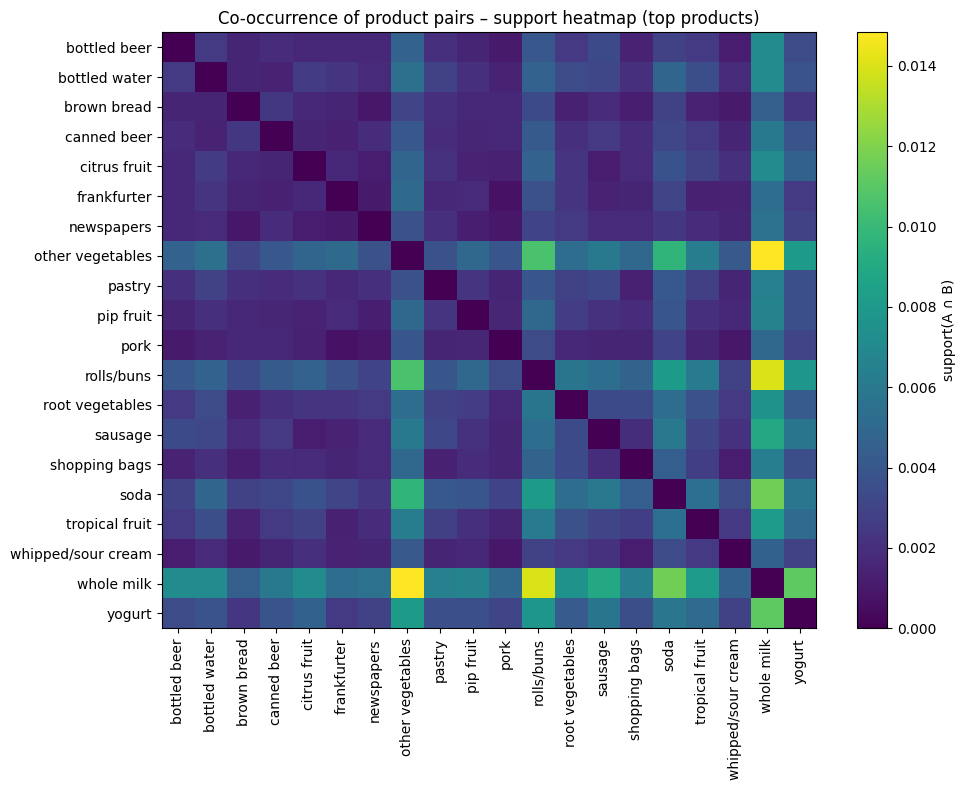

In [ ]:
import matplotlib.pyplot as plt

# support_sym: DataFrame (rows=A, columns=B, value=support)
plt.figure(figsize=(10, 8))

# Draw heatmap (based on matrix values)
plt.imshow(support_sym.values, aspect="auto")

# Color scale (what the colors represent)
plt.colorbar(label="support(A ∩ B)")

# Axis labels: product names
plt.xticks(range(len(support_sym.columns)), support_sym.columns, rotation=90)
plt.yticks(range(len(support_sym.index)), support_sym.index)

plt.title("Co-occurrence of product pairs – support heatmap (top products)")
plt.tight_layout()
plt.show()

### What does this heatmap show?

This is a **support heatmap** for the *top products*.

- Rows and columns represent product names (**A** and **B**).
- The value in each cell is **support(A ∩ B)**  
  → the percentage of baskets in which **A and B appear together**.
- The color scale represents this value:
  - **darker**: rare / close to 0
  - **lighter**: more frequent co-occurrence

**How to read it?**
- Look for the **lighter spots**: these are product pairs that are “frequently bought together”.
- The diagonal (A,A) is 0, because “a product with itself” is not meaningful here.
- The matrix appears “asymmetric” because in reality only one half of the matrix is filled.

### Advanced / extra analysis

- The following part is **not required**, it is only an extension: how frequent product pairs can be used to create **association rules**.
- In addition to **support**, we compute two additional metrics: **confidence** (how often B appears when A appears) and **lift** (whether there is an “extra relationship” between A and B).

- **confidence(A → B)** = if A is true, how often is B also true?
- **lift(A → B)** = how much more often B appears with A than “on average”?
  - lift > 1: positive relationship (occur together more frequently)
  - lift ≈ 1: independent
  - lift < 1: negative relationship (occur together less frequently)

In [ ]:
# confidence and lift
# definition: confidence(A -> B) = support(A ∩ B) / support(A)
# interpretation: if A is in the basket, how often is B also in the basket?
rules["confidence_A_to_B"] = rules["support_AB"] / rules["support_A"]

# calculation of lift(A -> B)
# definition: lift(A -> B) = confidence(A -> B) / support(B)
# interpretation: how much more frequent B is together with A compared to "on average"?
rules["lift_A_to_B"] = rules["confidence_A_to_B"] / rules["support_B"]

# (Recommended) filtering + sorting
min_support = 0.01
rules_sorted = (rules[rules["support_AB"] >= min_support]
                .sort_values(["lift_A_to_B", "support_AB"], ascending=False))

# Sorting: the most interesting rules appear at the top
rules_sorted.head(20)

,pair,support_AB,A,B,support_A,support_B,confidence_A_to_B,lift_A_to_B
3,"(whole milk, yogurt)",0.011161,whole milk,yogurt,0.157923,0.085879,0.070673,0.822940
1,"(rolls/buns, whole milk)",0.013968,rolls/buns,whole milk,0.110005,0.157923,0.126974,0.804028
4,"(other vegetables, rolls/buns)",0.010559,other vegetables,rolls/buns,0.122101,0.110005,0.086481,0.786154
0,"(other vegetables, whole milk)",0.014837,other vegetables,whole milk,0.122101,0.157923,0.121511,0.769430
2,"(soda, whole milk)",0.011629,soda,whole milk,0.097106,0.157923,0.119752,0.758296


### What do we see in this table?

This table shows **association rules** in the shopping basket dataset:  
**A → B** means that if **A** appears in a basket, how likely it is that **B** also appears.

**Columns:**
- **itemDescription** – the product pair (A, B) stored together
- **support_AB** – `support(A ∩ B)`  
  → the percentage of baskets in which **A and B appear together**
- **A, B** – the two products in separate columns
- **support_A**, **support_B** – `support(A)`, `support(B)`  
  → the percentage of baskets in which A (or B) appears individually
- **confidence_A_to_B** – `confidence(A → B) = support(A ∩ B) / support(A)`  
  → if A is in the basket, how often is B also present?
- **lift_A_to_B** – `lift(A → B) = confidence(A → B) / support(B)`  
  → how much more often B appears together with A than “on average”?
  - **lift > 1**: more frequent together (positive relationship)
  - **lift ≈ 1**: nearly independent
  - **lift < 1**: less frequent together

**Important note:**  
The table uses a `min_support = 0.01` filter, meaning only those pairs are kept
that appear together in at least **1%** of baskets.

## Exercises

### Exercise 1 – Top products vs. top product pairs (support only)

1. Print the **5 most frequent products** based on `support_1` (1-item support).
2. Print the **5 most frequent product pairs** based on `pair_support` (2-item support).
3. Answer briefly:
   - Is there a product that is **very frequent individually**, but **does not dominate in pairs**?
   - What does this tell us about the difference between a “frequent product” and “frequent co-purchase”?

In [7]:
import pandas as pd
from itertools import combinations

file_id = "1fmCcMbBwZrL6eNsv6Y9L_CxUx9VNPnSs"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url)

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df["transaction_id"] = df["Member_number"].astype(str) + "_" + df["Date"].dt.strftime("%Y-%m-%d")
transactions = df.groupby("transaction_id")["itemDescription"].apply(lambda s: sorted(set(s)))
N = len(transactions)

all_items = transactions.explode()
support_1 = (all_items.value_counts() / N).sort_values(ascending=False)

pairs = transactions.apply(lambda items: list(combinations(items, 2))).explode()
pair_support = (pairs.value_counts() / N).sort_values(ascending=False)

top_5_items = support_1.head(5)
top_5_pairs = pair_support.head(5)

print("Top 5 individual products by support:")
print(top_5_items)
print("\nTop 5 product pairs by support:")
print(top_5_pairs)

print("\nAnswer:")
print("Some products are very frequent individually but do not dominate in pairs, e.g., 'whole milk' may appear often alone but less often in combination with others.")
print("This shows that a frequent product is not necessarily frequently co-purchased and co-purchase depends on shopping patterns.")

Top 5 individual products by support:
itemDescription
whole milk          0.157923
other vegetables    0.122101
rolls/buns          0.110005
soda                0.097106
yogurt              0.085879
Name: count, dtype: float64

Top 5 product pairs by support:
itemDescription
(other vegetables, whole milk)    0.014837
(rolls/buns, whole milk)          0.013968
(soda, whole milk)                0.011629
(whole milk, yogurt)              0.011161
(other vegetables, rolls/buns)    0.010559
Name: count, dtype: float64

Answer:
Some products are very frequent individually but do not dominate in pairs, e.g., 'whole milk' may appear often alone but less often in combination with others.
This shows that a frequent product is not necessarily frequently co-purchased and co-purchase depends on shopping patterns.


### Exercise 2 – Effect of the support threshold (support only)

1. Choose two thresholds for product pairs, for example:
   - `min_support = 0.005`
   - `min_support = 0.02`
2. For both thresholds, count **how many product pairs** remain:
   - `pair_support[pair_support >= min_support]`
3. In both cases, print the **top 10** product pairs.
4. Answer briefly:
   - Why does the number of pairs decrease drastically when we increase the threshold?
   - In what case is it worth using a stricter threshold?

In [6]:
thresholds = [0.005, 0.02]

for t in thresholds:
    filtered_pairs = pair_support[pair_support >= t]
    print(f"\nThreshold = {t}: {len(filtered_pairs)} pairs remain")
    print(filtered_pairs.head(10))

print("\nAnswer:")
print("Increasing the support threshold drastically reduces the number of pairs because fewer combinations meet the stricter minimum frequency.")
print("A stricter threshold is worth using when focusing on the most important co-purchases and reducing noise from rare item pairs.")


Threshold = 0.005: 37 pairs remain
itemDescription
(other vegetables, whole milk)    0.014837
(rolls/buns, whole milk)          0.013968
(soda, whole milk)                0.011629
(whole milk, yogurt)              0.011161
(other vegetables, rolls/buns)    0.010559
(other vegetables, soda)          0.009691
(sausage, whole milk)             0.008955
(tropical fruit, whole milk)      0.008220
(other vegetables, yogurt)        0.008087
(rolls/buns, soda)                0.008087
Name: count, dtype: float64

Threshold = 0.02: 0 pairs remain
Series([], Name: count, dtype: float64)

Answer:
Increasing the support threshold drastically reduces the number of pairs because fewer combinations meet the stricter minimum frequency.
A stricter threshold is worth using when focusing on the most important co-purchases and reducing noise from rare item pairs.
